# **Outlier Analysis**

## **Import Library**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

## **Load Data**

In [3]:
df = pd.read_csv('ENV_data_2025-06-20.csv')
df = df.rename(columns={'created_at':'date', 'field1':'Temperature', 'field2':'Humidity', 'field3':'PM2.5', 'field4':'PM10', 'field5':'CO', 'field6':'CO2'})

In [4]:
df.head()

,date,entry_id,Temperature,Humidity,PM2.5,PM10,CO,CO2,latitude,longitude,elevation,status
0,2025-06-15T09:18:44+00:00,1,24.8,68.6,20.4,24.7,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-06-15T09:19:33+00:00,2,24.8,66.0,20.9,25.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-06-15T09:20:22+00:00,3,24.9,65.7,20.5,25.1,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-06-15T09:21:12+00:00,4,24.9,65.5,21.2,26.4,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-06-15T09:22:01+00:00,5,25.0,69.2,20.9,24.5,NaN,NaN,NaN,NaN,NaN,NaN


## **Data Preprocessing**

In [5]:
df.drop(['latitude', 'longitude', 'elevation', 'status'], axis=1, inplace=True)

In [6]:
df.isna().sum()

date             0
entry_id         0
Temperature      0
Humidity         0
PM2.5            0
PM10             0
CO             444
CO2            444
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.isna().sum()

date           0
entry_id       0
Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

In [9]:
df = df[(df['CO2'] >= 400) & (df['CO'] <= 100) & (df['CO'] > 0.1)]

In [10]:
df

,date,entry_id,Temperature,Humidity,PM2.5,PM10,CO,CO2
463,2025-06-17T07:08:50+00:00,464,25.9,71.3,26.4,35.1,1.32246,402.82861
464,2025-06-17T07:09:40+00:00,465,25.9,70.1,26.2,33.3,1.28997,402.73026
465,2025-06-17T07:10:36+00:00,466,25.9,69.7,24.5,32.5,1.31978,402.81689
466,2025-06-17T07:11:26+00:00,467,25.9,69.3,24.1,31.9,1.32873,402.75455
467,2025-06-17T07:12:15+00:00,468,25.8,69.1,25.1,32.0,1.30203,402.64542
...,...,...,...,...,...,...,...,...
4384,2025-06-19T17:33:48+00:00,4385,26.1,76.7,35.4,58.3,4.58933,406.10184
4385,2025-06-19T17:34:37+00:00,4386,26.1,76.7,36.1,54.2,4.24075,405.98636
4386,2025-06-19T17:35:27+00:00,4387,26.1,76.6,33.4,50.6,4.08809,406.09128
4387,2025-06-19T17:36:16+00:00,4388,26.1,76.6,34.4,50.7,4.72726,406.00723


In [11]:
df.to_csv("Preprocessed_ENV_data_2025-06-20.csv", index=False)

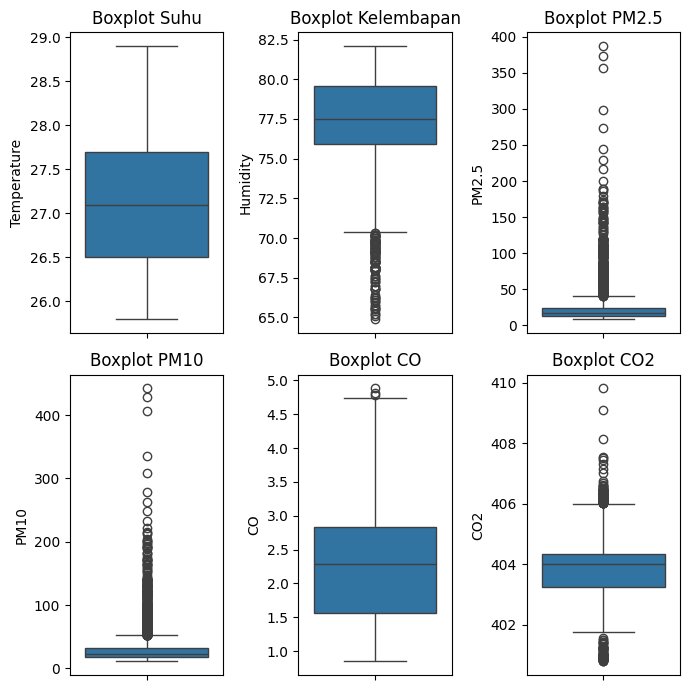

In [12]:
# Boxplot untuk cek outlier secara visual
plt.figure(figsize=(7,7))

plt.subplot(231)
sns.boxplot(data=df['Temperature'])
plt.title("Boxplot Suhu")

plt.subplot(232)
sns.boxplot(data=df['Humidity'])
plt.title("Boxplot Kelembapan")

plt.subplot(233)
sns.boxplot(data=df['PM2.5'])
plt.title("Boxplot PM2.5")

plt.subplot(234)
sns.boxplot(data=df['PM10'])
plt.title("Boxplot PM10")

plt.subplot(235)
sns.boxplot(data=df['CO'])
plt.title("Boxplot CO")

plt.subplot(236)
sns.boxplot(data=df['CO2'])
plt.title("Boxplot CO2")

plt.tight_layout()
plt.show()

## **Clustering**

In [13]:
features = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'CO', 'CO2']
X = df[features]

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **DBSCAN**

In [52]:
epsilons = np.linspace(0.2, 1.5, 20)
epsilons

array([0.2       , 0.26842105, 0.33684211, 0.40526316, 0.47368421,
       0.54210526, 0.61052632, 0.67894737, 0.74736842, 0.81578947,
       0.88421053, 0.95263158, 1.02105263, 1.08947368, 1.15789474,
       1.22631579, 1.29473684, 1.36315789, 1.43157895, 1.5       ])

In [53]:
min_samples = np.arange(2, 21, step=1)
min_samples

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20])

In [54]:
import itertools

combinations = list(itertools.product(epsilons, min_samples))
combinations

[(0.2, 2),
 (0.2, 3),
 (0.2, 4),
 (0.2, 5),
 (0.2, 6),
 (0.2, 7),
 (0.2, 8),
 (0.2, 9),
 (0.2, 10),
 (0.2, 11),
 (0.2, 12),
 (0.2, 13),
 (0.2, 14),
 (0.2, 15),
 (0.2, 16),
 (0.2, 17),
 (0.2, 18),
 (0.2, 19),
 (0.2, 20),
 (0.26842105263157895, 2),
 (0.26842105263157895, 3),
 (0.26842105263157895, 4),
 (0.26842105263157895, 5),
 (0.26842105263157895, 6),
 (0.26842105263157895, 7),
 (0.26842105263157895, 8),
 (0.26842105263157895, 9),
 (0.26842105263157895, 10),
 (0.26842105263157895, 11),
 (0.26842105263157895, 12),
 (0.26842105263157895, 13),
 (0.26842105263157895, 14),
 (0.26842105263157895, 15),
 (0.26842105263157895, 16),
 (0.26842105263157895, 17),
 (0.26842105263157895, 18),
 (0.26842105263157895, 19),
 (0.26842105263157895, 20),
 (0.33684210526315794, 2),
 (0.33684210526315794, 3),
 (0.33684210526315794, 4),
 (0.33684210526315794, 5),
 (0.33684210526315794, 6),
 (0.33684210526315794, 7),
 (0.33684210526315794, 8),
 (0.33684210526315794, 9),
 (0.33684210526315794, 10),
 (0.33684210

In [55]:
N = len(combinations)
N

380

In [56]:
def get_scores_and_labels(combinations, X_scaled):
  scores = []
  all_labels_list = []

  for i, (eps, num_samples) in enumerate(combinations):
    dbscan_model = DBSCAN(eps=eps, min_samples=num_samples).fit(X_scaled)
    labels = dbscan_model.labels_
    labels_set = set(labels)
    num_clusters = len(labels_set)
    if -1 in labels_set:
      num_clusters -= 1
    
    if (num_clusters < 2) or (num_clusters > 50):
      scores.append(-10)
      all_labels_list.append('bad')
      c = (eps, num_samples)
      print(f"Combination {c} on iteration {i+1} of {N} has {num_clusters} clusters. Moving on")
      continue
    
    scores.append(silhouette_score(X_scaled[labels != -1], labels[labels != -1]))
    all_labels_list.append(labels)
    print(f"Index: {i}, Score: {scores[-1]}, Labels: {all_labels_list[-1]}, NumClusters: {num_clusters}")

  best_index = np.argmax(scores)
  best_parameters = combinations[best_index]
  best_labels = all_labels_list[best_index]
  best_score = scores[best_index]

  return {'best_epsilon': best_parameters[0],
          'best_min_samples': best_parameters[1], 
          'best_labels': best_labels,
          'best_score': best_score}

best_dict = get_scores_and_labels(combinations, X_scaled)

Combination (0.2, 2) on iteration 1 of 380 has 70 clusters. Moving on
Index: 1, Score: 0.11657258023758241, Labels: [-1  0  0 ... -1 -1 -1], NumClusters: 48
Index: 2, Score: 0.12031245328339131, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 39
Index: 3, Score: 0.1895822314970604, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 31
Index: 4, Score: 0.19044034743024627, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 31
Index: 5, Score: 0.22218564993165543, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 35
Index: 6, Score: 0.21979719164034736, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 35
Index: 7, Score: 0.23408802663752434, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 35
Index: 8, Score: 0.21452416777866598, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 37
Index: 9, Score: 0.2523829028976948, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 35
Index: 10, Score: 0.24154011992198363, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 34
Index: 11, Score: 0.2763675489750788, Labels: [-1 -1 -1 ... -

In [57]:
best_dict

{'best_epsilon': 1.431578947368421,
 'best_min_samples': 3,
 'best_labels': array([0, 0, 0, ..., 0, 0, 0], dtype=int64),
 'best_score': 0.838334037219184}

In [58]:
values, counts = np.unique(best_dict['best_labels'], return_counts=True)
print(values)
print(counts)

[-1  0  1]
[   4 3919    3]


In [74]:
df_dbscan = df.copy()
df_dbscan['dbscan_label'] = best_dict['best_labels']
df_dbscan['sensor_fault'] = df_dbscan['dbscan_label'] == -1
print(df_dbscan['sensor_fault'].value_counts())

sensor_fault
False    3922
True        4
Name: count, dtype: int64


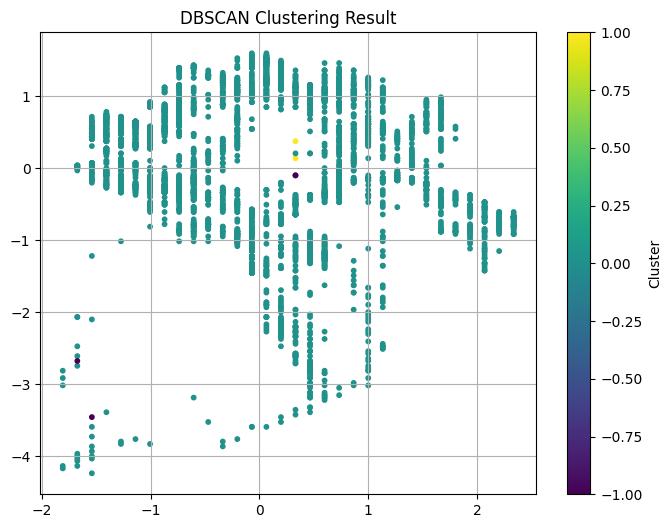

In [76]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df_dbscan['dbscan_label'], cmap='viridis', s=10)
plt.colorbar(label='Cluster')
plt.title("DBSCAN Clustering Result")
plt.grid(True)
plt.show()


In [37]:
best_score = -1
best_params = None

for eps in [0.5, 1.0, 1.5, 2.0]:
    for min_samples in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_
        unique_labels = set(labels)

        # Hanya hitung score jika ada >= 2 cluster valid (selain -1)
        if len(unique_labels - {-1}) >= 2:
            score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)


In [38]:
best_score

0.4371726658674532

In [39]:
best_params

(1.5, 15)

### **KMEANS**

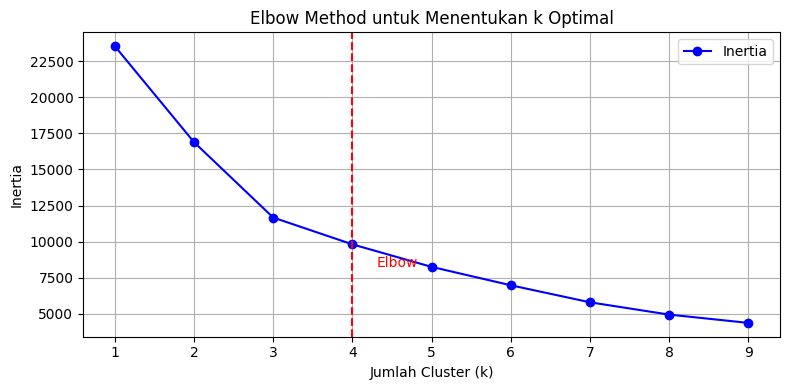

In [59]:
# Hitung inertia untuk berbagai nilai k
k_range = range(1, 10)
kmeans_per_k = [KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42).fit(X_scaled) for k in k_range]
inertias = [model.inertia_ for model in kmeans_per_k]

# Plot
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, "bo-", label="Inertia")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method untuk Menentukan k Optimal")

# Garis vertikal untuk elbow (jika sudah ditentukan)
elbow_k = 4
plt.axvline(elbow_k, color='red', linestyle='--')
plt.text(elbow_k + 0.3, inertias[elbow_k], "Elbow", color='red')

plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, random_state=42)

In [61]:
df_kmeans = df.copy()
df_kmeans['cluster'] = kmeans.labels_

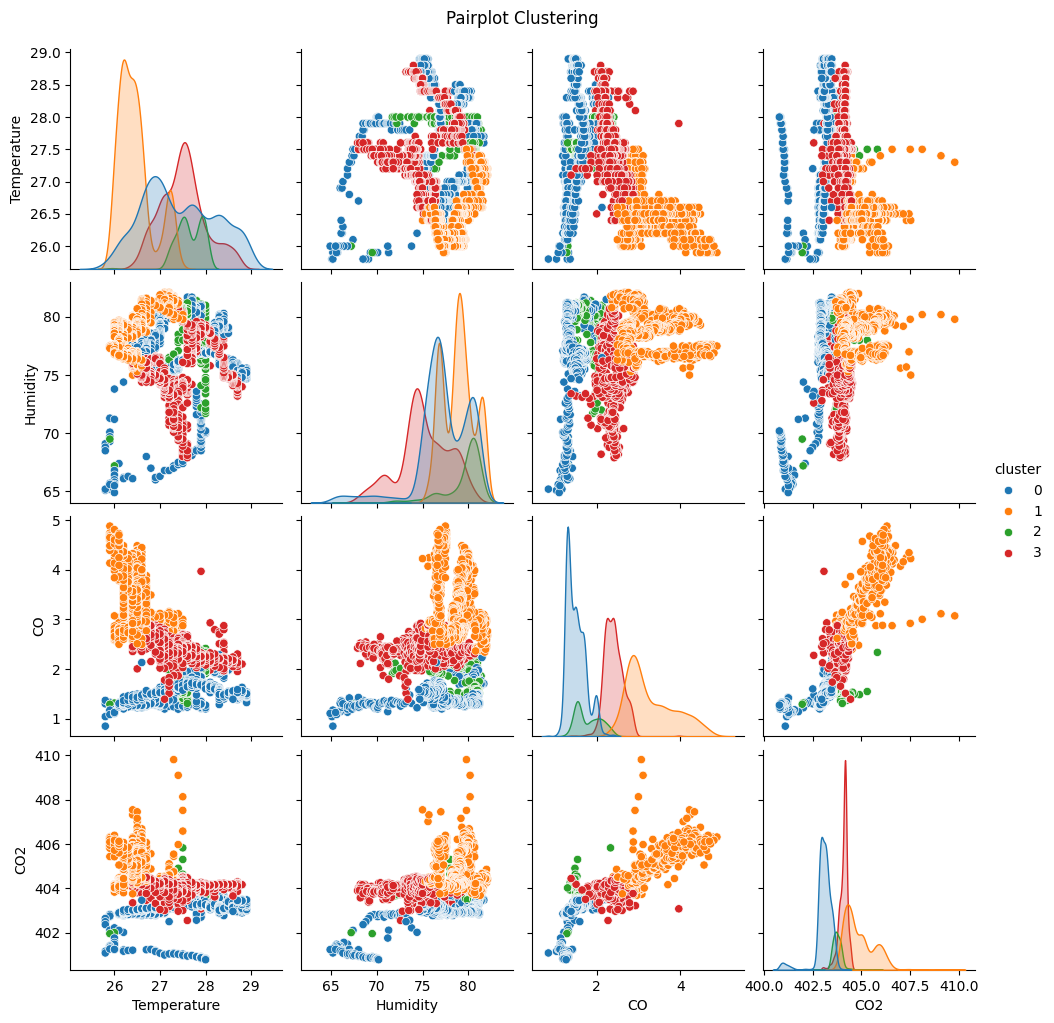

In [62]:
# Tambahkan cluster ke salinan data
df_clustered = df.copy()
sns.pairplot(df_kmeans, vars=['Temperature', 'Humidity', 'CO', 'CO2'], hue='cluster', palette='tab10')
plt.suptitle("Pairplot Clustering", y=1.02)
plt.show()

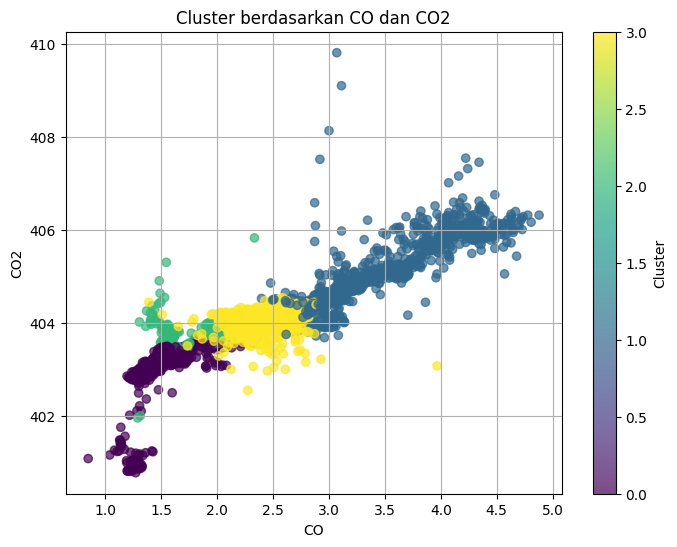

In [63]:
plt.figure(figsize=(8, 6))
plt.scatter(df_kmeans['CO'], df_kmeans['CO2'], c=df_kmeans['cluster'], alpha=0.7)
plt.xlabel('CO')
plt.ylabel('CO2')
plt.title('Cluster berdasarkan CO dan CO2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

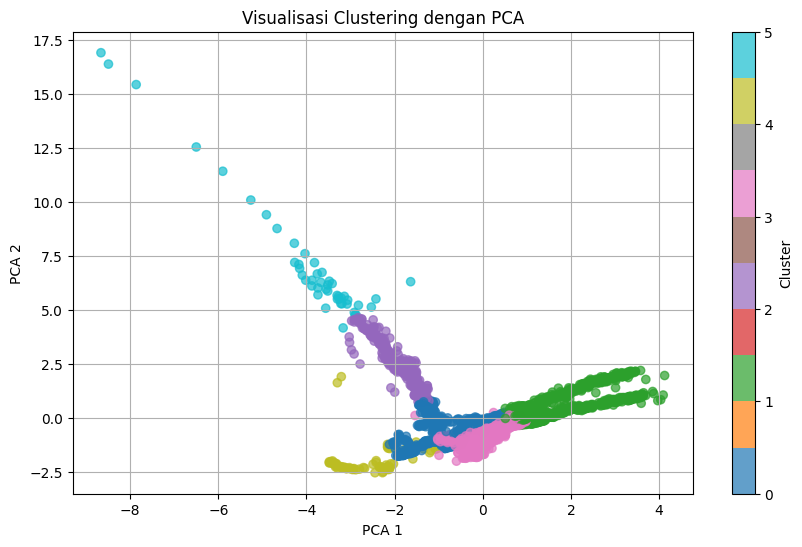

In [18]:
from sklearn.decomposition import PCA

# Reduksi dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisasi
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='tab10', alpha=0.7)
plt.title('Visualisasi Clustering dengan PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()


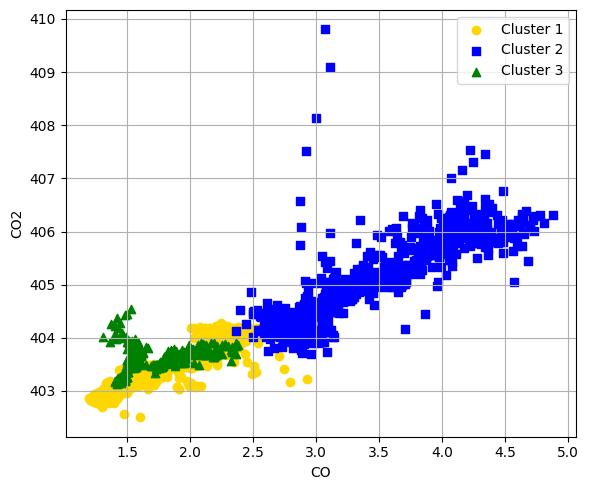

In [19]:
# Contoh: menggunakan dua fitur
x = df['CO']
y = df['CO2']

# Loop per cluster
plt.figure(figsize=(6, 5))
for cluster_id, marker, color in zip(range(3), ['o', 's', '^'], ['gold', 'blue', 'green']):
    cluster_data = df[df['cluster'] == cluster_id]
    plt.scatter(cluster_data['CO'], cluster_data['CO2'],
                label=f'Cluster {cluster_id+1}',
                marker=marker,
                color=color)

# Label dan gaya
plt.xlabel("CO")
plt.ylabel("CO2")
plt.legend()
plt.grid(True)
plt.tight_layout()

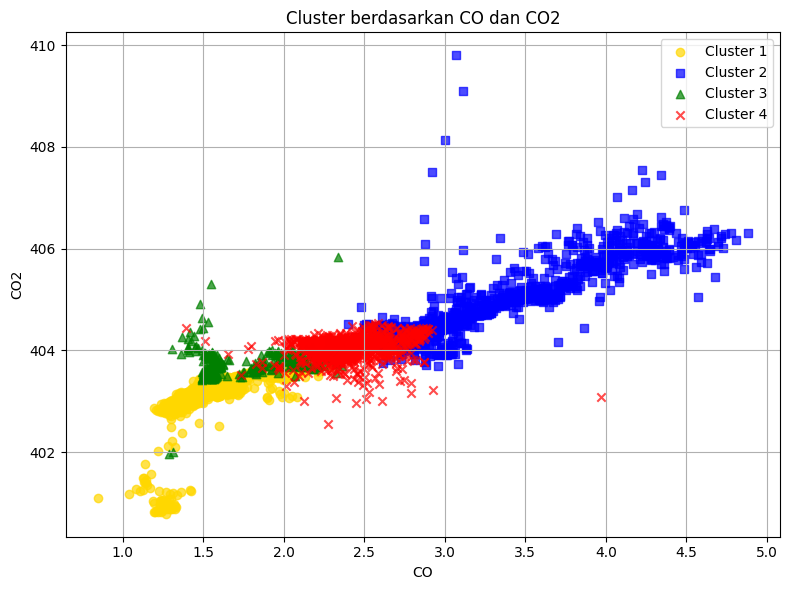

In [64]:
import matplotlib.pyplot as plt

# Warna untuk tiap cluster
colors = ['gold', 'blue', 'green', 'red']  # Bisa disesuaikan
markers = ['o', 's', '^', 'x']  # Marker unik per cluster

plt.figure(figsize=(8, 6))

for cluster_id in sorted(df_kmeans['cluster'].unique()):
    cluster_data = df_kmeans[df_kmeans['cluster'] == cluster_id]
    plt.scatter(cluster_data['CO'], cluster_data['CO2'],
                color=colors[cluster_id % len(colors)],
                marker=markers[cluster_id % len(markers)],
                label=f'Cluster {cluster_id + 1}',
                alpha=0.7)

plt.xlabel('CO')
plt.ylabel('CO2')
plt.title('Cluster berdasarkan CO dan CO2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [65]:
from sklearn.metrics import pairwise_distances_argmin_min

# Hitung jarak tiap titik ke centroid-nya
_, distances = pairwise_distances_argmin_min(X_scaled, kmeans.cluster_centers_)

# Tambahkan ke dataframe
df_kmeans['distance_to_center'] = distances

# Tandai sebagai fault jika jarak terlalu jauh (misal di atas percentile ke-95)
threshold = df_kmeans['distance_to_center'].quantile(0.95)
df_kmeans['sensor_fault'] = df_kmeans['distance_to_center'] > threshold

In [66]:
df_kmeans

,date,entry_id,Temperature,Humidity,PM2.5,PM10,CO,CO2,cluster,distance_to_center,sensor_fault
463,2025-06-17T07:08:50+00:00,464,25.9,71.3,26.4,35.1,1.32246,402.82861,0,2.910439,True
464,2025-06-17T07:09:40+00:00,465,25.9,70.1,26.2,33.3,1.28997,402.73026,0,3.212918,True
465,2025-06-17T07:10:36+00:00,466,25.9,69.7,24.5,32.5,1.31978,402.81689,0,3.299817,True
466,2025-06-17T07:11:26+00:00,467,25.9,69.3,24.1,31.9,1.32873,402.75455,0,3.409266,True
467,2025-06-17T07:12:15+00:00,468,25.8,69.1,25.1,32.0,1.30203,402.64542,0,3.560046,True
...,...,...,...,...,...,...,...,...,...,...,...
4384,2025-06-19T17:33:48+00:00,4385,26.1,76.7,35.4,58.3,4.58933,406.10184,1,2.539625,True
4385,2025-06-19T17:34:37+00:00,4386,26.1,76.7,36.1,54.2,4.24075,405.98636,1,2.184778,False
4386,2025-06-19T17:35:27+00:00,4387,26.1,76.6,33.4,50.6,4.08809,406.09128,1,2.096237,False
4387,2025-06-19T17:36:16+00:00,4388,26.1,76.6,34.4,50.7,4.72726,406.00723,1,2.503280,True


In [67]:
print(df_kmeans['sensor_fault'].value_counts())  # Jumlah data normal vs fault


sensor_fault
False    3729
True      197
Name: count, dtype: int64


C:\Users\Muhammad Mahdi\AppData\Local\Temp\ipykernel_1808\4131939143.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


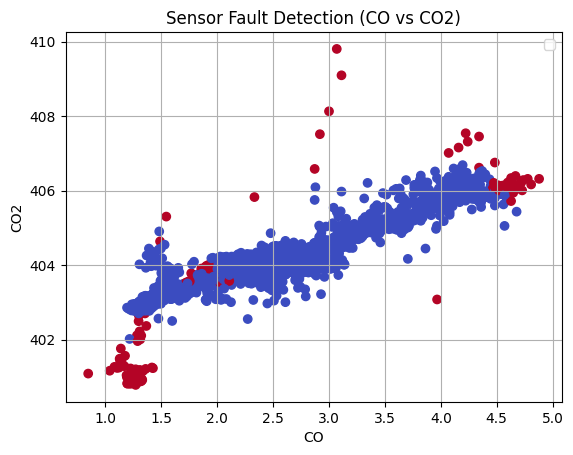

In [71]:
plt.scatter(df_kmeans['CO'], df_kmeans['CO2'], c=df_kmeans['sensor_fault'], cmap='coolwarm')
plt.title('Sensor Fault Detection (CO vs CO2)')
plt.xlabel('CO')
plt.ylabel('CO2')
plt.legend()
plt.grid(True)
plt.show()


In [25]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.0, min_samples=10)
labels = dbscan.fit_predict(X_scaled)

df['dbscan_label'] = labels
df['sensor_fault'] = df['dbscan_label'] == -1  # -1 = outlier


C:\Users\Muhammad Mahdi\AppData\Local\Temp\ipykernel_23368\235161416.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dbscan_label'] = labels
C:\Users\Muhammad Mahdi\AppData\Local\Temp\ipykernel_23368\235161416.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sensor_fault'] = df['dbscan_label'] == -1  # -1 = outlier


In [26]:
df

,date,entry_id,Temperature,Humidity,PM2.5,PM10,CO,CO2,cluster,distance_to_center,sensor_fault,dbscan_label
463,2025-06-17T07:08:50+00:00,464,25.9,71.3,26.4,35.1,1.32246,402.82861,4,2.249504,True,-1
464,2025-06-17T07:09:40+00:00,465,25.9,70.1,26.2,33.3,1.28997,402.73026,4,2.037144,True,-1
465,2025-06-17T07:10:36+00:00,466,25.9,69.7,24.5,32.5,1.31978,402.81689,4,2.070788,True,-1
466,2025-06-17T07:11:26+00:00,467,25.9,69.3,24.1,31.9,1.32873,402.75455,4,2.004199,False,0
467,2025-06-17T07:12:15+00:00,468,25.8,69.1,25.1,32.0,1.30203,402.64542,4,2.019172,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4384,2025-06-19T17:33:48+00:00,4385,26.1,76.7,35.4,58.3,4.58933,406.10184,1,2.505034,False,2
4385,2025-06-19T17:34:37+00:00,4386,26.1,76.7,36.1,54.2,4.24075,405.98636,1,2.150115,False,2
4386,2025-06-19T17:35:27+00:00,4387,26.1,76.6,33.4,50.6,4.08809,406.09128,1,2.061090,False,2
4387,2025-06-19T17:36:16+00:00,4388,26.1,76.6,34.4,50.7,4.72726,406.00723,1,2.467515,False,2


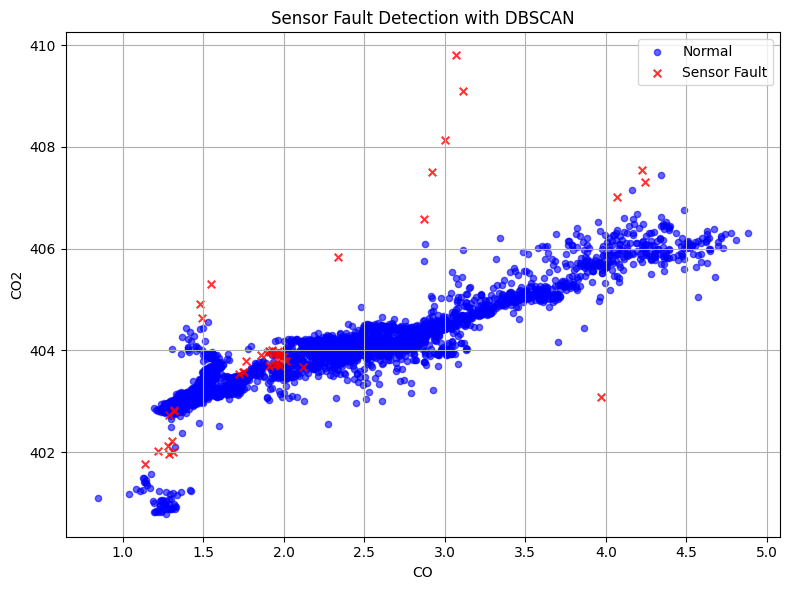

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df[df['sensor_fault'] == False]['CO'],
            df[df['sensor_fault'] == False]['CO2'],
            label='Normal', alpha=0.6, c='blue', s=20)

plt.scatter(df[df['sensor_fault'] == True]['CO'],
            df[df['sensor_fault'] == True]['CO2'],
            label='Sensor Fault', alpha=0.8, c='red', s=30, marker='x')

plt.xlabel('CO')
plt.ylabel('CO2')
plt.title('Sensor Fault Detection with DBSCAN')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


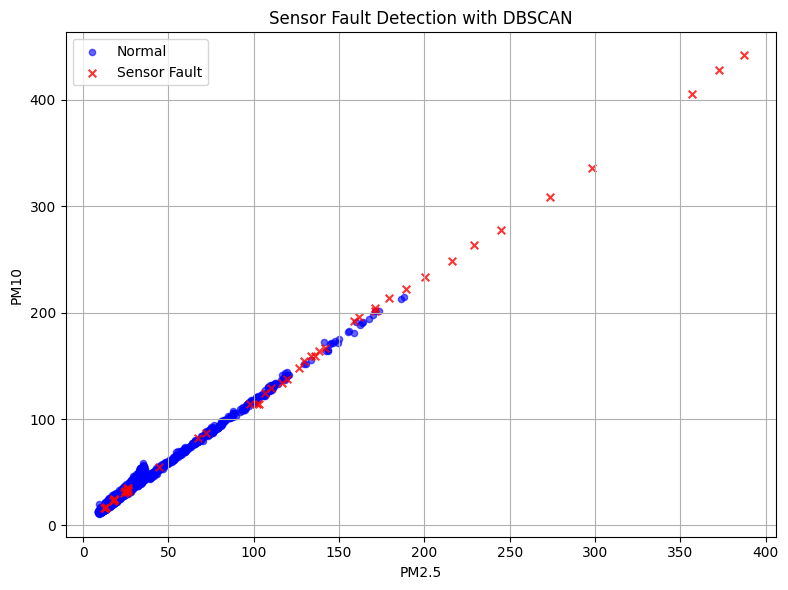

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(df[df['sensor_fault'] == False]['PM2.5'],
            df[df['sensor_fault'] == False]['PM10'],
            label='Normal', alpha=0.6, c='blue', s=20)

plt.scatter(df[df['sensor_fault'] == True]['PM2.5'],
            df[df['sensor_fault'] == True]['PM10'],
            label='Sensor Fault', alpha=0.8, c='red', s=30, marker='x')

plt.xlabel('PM2.5')
plt.ylabel('PM10')
plt.title('Sensor Fault Detection with DBSCAN')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()